# Fabric Defect Classification — Baseline CNN

**Notebook 03** of the fabric defect classification pipeline.

This notebook trains a **simple convolutional neural network built from scratch** and measures how well it performs.

**Why build this before ResNet18?** The project's claim is that transfer learning helps. A strong ResNet18 score on its own would not show that — perhaps the task was easy and any network would have managed it. Training an ordinary CNN from scratch answers the question directly: whatever it achieves is what this dataset yields *without* outside knowledge, so anything ResNet18 gains beyond it comes from the pretraining.

| Model | Role |
|---|---|
| **Baseline CNN** *(this notebook)* | Trained from scratch on these 2,737 images alone |
| **ResNet18** *(Notebook 04)* | Transfer learning from ImageNet — the main model |

### How we measure success

"defect free" makes up 60% of the data and the largest class is 62 times the smallest, so accuracy is easy to inflate simply by favouring the common classes. We therefore report:

- **Macro F1** as the headline, which treats all nine classes as equally important
- **Recall for each class separately**, so the rare defects cannot hide behind the common ones

## 1. Setup

**What:** Load the libraries, find the cleaned data from Notebook 02, and pick a device to train on.

**Why:** Notebook 02 saved the processed images along with `manifest.csv` (which lists each image's class and fold) and `class_weights.json`. Where those files live depends on how you are running — inside the same Kaggle session, from an attached dataset, or on your own machine — so we check each possible location in turn.

Setting a fixed random seed matters more than it might seem. Training involves randomness at every step: how weights start, how images are shuffled, which augmentations are applied. Fixing the seed means re-running this notebook gives the same numbers, so any improvement we see later comes from the change we made rather than luck.

In [1]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3
SEED = 42
NUM_WORKERS = 2
N_FOLDS = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CANDIDATES = [
    Path("/content/data/processed"),          # Colab local disk
    Path("/kaggle/working/processed"),        # Kaggle same session
]
kaggle_input = Path("/kaggle/input")
if kaggle_input.exists():
    CANDIDATES += sorted(kaggle_input.glob("*/processed"))   # attached notebook output
    CANDIDATES += sorted(kaggle_input.glob("*"))             # dataset attached at its root
CANDIDATES.append(Path("data/processed"))                    # local machine

DATA_DIR = next((c for c in CANDIDATES if (c / "manifest.csv").exists()), None)

MODEL_NAME = "baseline_cnn"

if Path("/kaggle/working").exists():
    OUTPUTS_ROOT = Path("/kaggle/working/outputs")
elif Path("/content").exists():
    OUTPUTS_ROOT = Path("/content/outputs")
else:
    OUTPUTS_ROOT = Path("outputs")

RESULTS_DIR = OUTPUTS_ROOT / MODEL_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("models") if Path("models").exists() else OUTPUTS_ROOT.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ASSETS_DIR = Path("assets") if Path("assets").exists() else None

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device  :", device)
print("Results :", RESULTS_DIR.resolve())
print("Data    :", DATA_DIR if DATA_DIR else "not found - the next cell will rebuild it")
print("Models  :", MODELS_DIR)

Device  : cuda
Results : /content/outputs/baseline_cnn
Data    : not found - the next cell will rebuild it
Models  : /content/models


### If the processed data is missing

Seeing `Data : not found` above is normal, not an error.

Both Colab and Kaggle give every notebook its own separate machine. Notebook 02 wrote its results to that machine's temporary disk, so this notebook cannot see them — and neither can any future session.

Rather than shuttling files between sessions, the cell below simply rebuilds the cleaned dataset from the raw images. It repeats exactly what Notebook 02 did: the same three-pass duplicate removal, the same conversion to 224×224 colour images, and the same random seed — so the folds come out identical and results stay comparable.

It takes about five minutes, mostly re-downloading the raw images. If the data *is* already present, the cell does nothing and finishes instantly.

In [2]:
if DATA_DIR is None:
    import hashlib
    import os
    import shutil
    from collections import Counter

    from sklearn.model_selection import StratifiedKFold

    print("Processed data not found - rebuilding it from the raw dataset.\n")

    ds2 = "/kaggle/input/multi-class-fabric-defect-detection-dataset/Dataset"
    if not os.path.exists(ds2):
        import kagglehub
        ds2 = os.path.join(
            kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset"),
            "Dataset",
        )
    raw_classes = sorted(os.listdir(ds2))
    print("Raw dataset:", ds2)

    def dhash(path, size=16):
        with Image.open(path) as img:
            small = img.convert("L").resize((size + 1, size), Image.BILINEAR)
        px = list(small.getdata())
        bits = []
        for row in range(size):
            for col in range(size):
                left = px[row * (size + 1) + col]
                right = px[row * (size + 1) + col + 1]
                bits.append("1" if left > right else "0")
        return "".join(bits)

    candidates = [
        (cls, p)
        for cls in raw_classes
        for p in sorted((Path(ds2) / cls).glob("*"))
        if "_processed" not in p.name
    ]
    print(f"After removing _processed     : {len(candidates)}")

    seen_md5, after_exact = set(), []
    for cls, p in candidates:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in seen_md5:
            continue
        seen_md5.add(h)
        after_exact.append((cls, p))
    print(f"After removing exact copies   : {len(after_exact)}")

    seen_dhash, keep = set(), []
    for cls, p in after_exact:
        key = (cls, dhash(p))
        if key in seen_dhash:
            continue
        seen_dhash.add(key)
        keep.append((cls, p))
    print(f"After removing near-duplicates: {len(keep)}\n")

    labels = [cls for cls, _ in keep]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_of = {}
    for fold_idx, (_, test_idx) in enumerate(skf.split(range(len(keep)), labels)):
        for i in test_idx:
            fold_of[i] = fold_idx

    OUT = Path("/kaggle/working/processed") if Path("/kaggle/working").exists() \
        else Path("data/processed")
    if OUT.exists():
        shutil.rmtree(OUT)
    (OUT / "images").mkdir(parents=True)

    rows = []
    for i, (cls, p) in enumerate(keep):
        cls_dir = OUT / "images" / cls
        cls_dir.mkdir(exist_ok=True)
        name = f"{i:05d}.jpg"
        with Image.open(p) as im:
            im.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR).save(
                cls_dir / name, quality=95)
        rows.append({
            "filepath": str(Path("images") / cls / name),
            "class": cls,
            "fold": fold_of[i],
            "source_file": p.name,
        })
    pd.DataFrame(rows).to_csv(OUT / "manifest.csv", index=False)

    counts = Counter(labels)
    total_imgs = len(labels)
    weights = {c: total_imgs / (len(raw_classes) * counts[c]) for c in raw_classes}
    with open(OUT / "class_weights.json", "w") as f:
        json.dump(weights, f, indent=2)

    DATA_DIR = OUT
    print("Rebuilt at:", DATA_DIR.resolve())
else:
    print("Using the processed data already found at:", DATA_DIR)

Processed data not found - rebuilding it from the raw dataset.



100%|██████████| 2.10G/2.10G [00:25<00:00, 90.1MB/s]

Extracting files...


Raw dataset: /root/.cache/kagglehub/datasets/ziya07/multi-class-fabric-defect-detection-dataset/versions/3/Dataset
After removing _processed     : 2758
After removing exact copies   : 2741
After removing near-duplicates: 2737

Rebuilt at: /content/data/processed


In [3]:
manifest = pd.read_csv(DATA_DIR / "manifest.csv")
class_weights_raw = json.load(open(DATA_DIR / "class_weights.json"))
class_names = sorted(manifest["class"].unique())
n_classes = len(class_names)
cls_to_idx = {c: i for i, c in enumerate(class_names)}

print(f"Images : {len(manifest)}")
print(f"Classes: {n_classes}")
print(f"Folds  : {manifest['fold'].nunique()}")
print()
print(manifest["class"].value_counts().to_string())

Images : 2737
Classes: 9
Folds  : 5

class
defect free       1663
stain              398
lines              146
hole               141
Broken stitch      112
Needle mark        108
Pinched fabric     108
horizontal          34
Vertical            27


**Observations:** All 2,737 images loaded, in 9 classes and 5 folds — the same as Notebook 02. The rebuild produced the same dataset, which is what the fixed random seed is for.

## 2. Loading and Augmenting the Images

**What:** Define how images are read and randomly altered during training.

**Why augment at all?** We have 2,737 images and only about 32 in the smallest class. A network with hundreds of thousands of parameters can simply memorise a set that small — scoring perfectly on training images while failing on anything new. Augmentation shows the model a slightly different version of each image every time it sees it: flipped, rotated a little, brighter or dimmer. The model can no longer memorise exact pictures, so it is pushed towards learning what a defect actually looks like.

**One augmentation we must not use.** Rotating an image by 90° would turn a *vertical* defect into a *horizontal* one — while the label still says "Vertical". We would be generating deliberately wrong training data for the two classes that are already the smallest and hardest.

Flips are safe, which is worth being clear about: a vertical line flipped left-to-right is still a vertical line. Only rotation changes direction, so rotations stay small (±10°).

**Why change the colours.** Notebook 01 found the dataset was assembled from several collections with different cameras and lighting. Randomly shifting brightness, contrast and colour makes those source differences unreliable as a clue, pushing the model to focus on fabric texture instead. Occasionally converting an image to grayscale does the same job more forcefully.

**Why normalise.** We subtract a fixed mean and divide by a fixed standard deviation so that pixel values are centred around zero, which helps training converge. We use the standard ImageNet values so this pipeline carries over unchanged to Notebook 04's pretrained model.

Note that augmentation applies **only during training**. When measuring performance we use the plain image, because the score should reflect real data rather than randomly distorted data.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),                       # small only - see note above
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class FabricDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.root / row["filepath"]).convert("RGB")
        return self.transform(img), cls_to_idx[row["class"]]

print("Transforms ready.")
print("Train pipeline:", len(train_tf.transforms), "steps")
print("Eval pipeline :", len(eval_tf.transforms), "steps")

Transforms ready.
Train pipeline: 7 steps
Eval pipeline : 2 steps


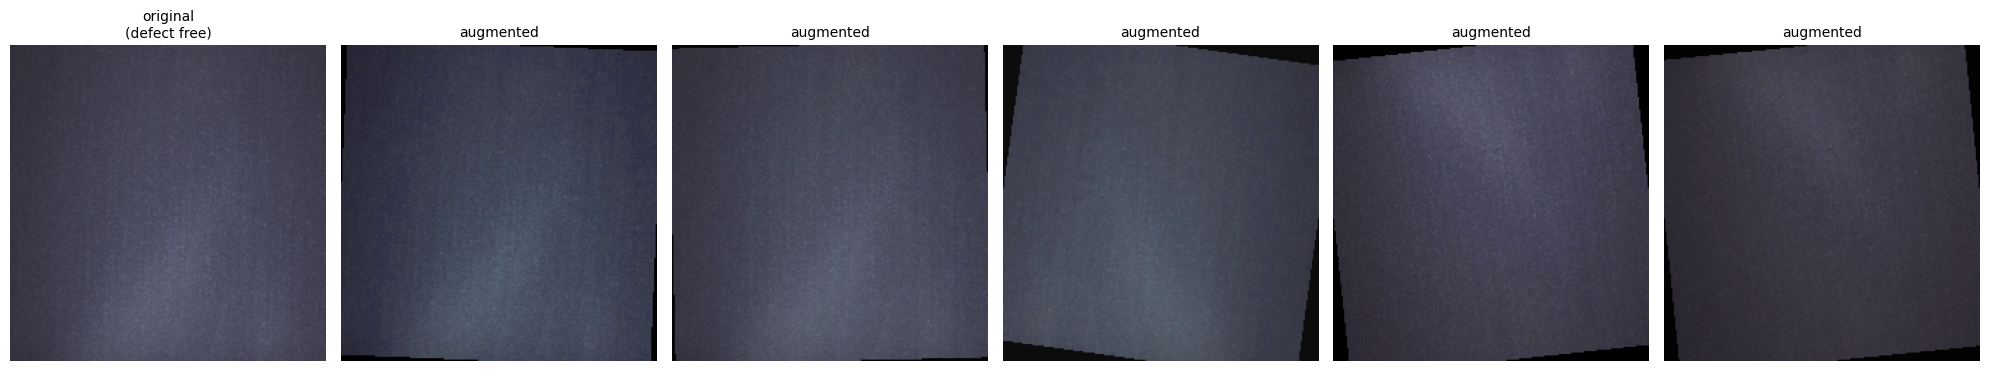

In [6]:
sample_row = manifest.sample(1, random_state=SEED).iloc[0]
sample_img = Image.open(DATA_DIR / sample_row["filepath"]).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
axes[0].imshow(sample_img)
axes[0].set_title(f"original\n({sample_row['class']})", fontsize=10)
axes[0].axis("off")

for ax in axes[1:]:
    aug = train_tf(sample_img)
    shown = aug * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    ax.imshow(shown.permute(1, 2, 0).clamp(0, 1))
    ax.set_title("augmented", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Observations:** The augmentation works, but the image picked here happens to be a *defect free* one, so it does not show whether a defect survives the process. Worth running the cell again to get a defective image.

Two things stand out. The small rotation leaves **black triangles in the corners**, cutting off a little of the fabric. And the colour changes make the six versions clearly lighter, darker, or differently tinted.

Both are meant to happen. The model sees a slightly different version of every image each time, so it cannot simply memorise the 2,737 originals. These changes are applied only during training, never when scoring, so they cannot inflate the results.

## 3. The Baseline CNN

**What:** Build a small convolutional network from scratch.

**Why this design?** The network stacks four blocks, each containing:

- a **convolution**, which scans the image for small patterns — early blocks find edges and texture, later blocks combine those into larger shapes like a hole or a stitch line
- **batch normalisation**, which keeps the numbers flowing through the network in a stable range and makes training much faster
- a **ReLU**, which lets the network model complicated relationships rather than just straight-line ones
- **max pooling**, which halves the image size, so later blocks see a wider area of the original picture

Channels double at each block (32 → 64 → 128 → 256): as the picture gets smaller, the network can afford to look for more distinct kinds of pattern.

At the end, **global average pooling** collapses each channel to a single number, then **dropout** randomly switches off half the values during training. Dropout is important here — with only 2,737 images, it stops the network leaning too heavily on any one feature and helps it generalise.

This is deliberately a *modest* network. It is not meant to be the best model we can build; it is meant to be an honest measure of what an ordinary CNN achieves on this data without any outside knowledge.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, dropout=0.5):
        super().__init__()

        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),      # 224 -> 112
            block(32, 64),     # 112 -> 56
            block(64, 128),    # 56  -> 28
            block(128, 256),   # 28  -> 14
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

model = SimpleCNN(n_classes)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0

**Observations:** The network has **391,689 parameters** but only 2,737 images to learn from — about **143 parameters for every image**.

This is the main difficulty. A network this big can simply memorise a dataset this small: it would score well on images it has already seen and fail on new ones. Dropout and augmentation are there to stop that, and the learning curves in §5 show whether they worked.

## 4. Training One Fold

**What:** Define the routine that trains the model once and measures it on held-out images.

**Why weight the loss?** Notebook 02 calculated a weight for each class based on how rare it is. We pass those weights into the loss function so that misclassifying a "Vertical" image costs far more than misclassifying a "defect free" one. Without this, the model quickly discovers it can score 60% by always answering "defect free", and training would push it straight towards that dead end.

**Why a fixed number of epochs instead of stopping early?** A common technique is to watch performance on held-out data and stop when it stops improving. We deliberately do not do that here. The held-out fold is what we use to *report* our score, so using it to decide when to stop would mean peeking at the answer — the reported number would look better than the model truly deserves.

Instead we train for a fixed 25 epochs every time and report the result at the end. We still record the held-out score after each epoch, but only to draw a learning curve and check that training behaved sensibly.

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, all_preds, all_true = 0.0, [], []
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_preds.append(out.argmax(1).cpu())
            all_true.append(y.cpu())

    preds = torch.cat(all_preds).numpy()
    true = torch.cat(all_true).numpy()
    return total_loss / len(loader.dataset), preds, true

def train_fold(fold, verbose=True):
    train_df = manifest[manifest["fold"] != fold]
    test_df = manifest[manifest["fold"] == fold]

    train_loader = DataLoader(
        FabricDataset(train_df, DATA_DIR, train_tf),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=False)
    test_loader = DataLoader(
        FabricDataset(test_df, DATA_DIR, eval_tf),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    torch.manual_seed(SEED + fold)
    model = SimpleCNN(n_classes).to(device)

    weights = torch.tensor([class_weights_raw[c] for c in class_names],
                           dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    history = []
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_pred, tr_true = run_epoch(model, train_loader, criterion, optimizer)
        te_loss, te_pred, te_true = run_epoch(model, test_loader, criterion)

        tr_f1 = f1_score(tr_true, tr_pred, average="macro", zero_division=0)
        te_f1 = f1_score(te_true, te_pred, average="macro", zero_division=0)
        history.append({"epoch": epoch, "train_loss": tr_loss, "test_loss": te_loss,
                        "train_f1": tr_f1, "test_f1": te_f1})

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  epoch {epoch:2d}/{EPOCHS}  "
                  f"train loss {tr_loss:.3f} f1 {tr_f1:.3f}  |  "
                  f"held-out loss {te_loss:.3f} f1 {te_f1:.3f}")

    return model, pd.DataFrame(history), te_pred, te_true, test_df.index.values

print("Training routine defined.")

Training routine defined.


## 5. Train Across All Five Folds

**What:** Train the network five times, each time holding out a different fold for testing.

**Why:** Notebook 02 split the data into five folds precisely for this. Each image is held out exactly once, so at the end we have a prediction for **every image in the dataset**, each made by a model that never saw that image during training.

This matters most for the rare classes. A single 15% test split would leave "Vertical" with about 5 test images, and a score based on 5 images swings wildly by chance. Across five folds we get predictions for all ~32, which is enough for the number to mean something.

Training five models takes roughly five times as long as training one. Expect several minutes per fold on a GPU, considerably longer on a laptop.

In [9]:
oof_pred = np.zeros(len(manifest), dtype=int)
oof_true = np.zeros(len(manifest), dtype=int)
histories, fold_scores = [], []

start = time.time()
for fold in sorted(manifest["fold"].unique()):
    print(f"\nFold {fold}")
    model, hist, pred, true, idx = train_fold(fold)

    oof_pred[idx] = pred
    oof_true[idx] = true
    hist["fold"] = fold
    histories.append(hist)

    f1 = f1_score(true, pred, average="macro", zero_division=0)
    acc = (pred == true).mean()
    fold_scores.append({"fold": fold, "macro_f1": f1, "accuracy": acc})

    torch.save(model.state_dict(), MODELS_DIR / f"{MODEL_NAME}_fold{fold}.pt")
    print(f"  -> macro F1 {f1:.3f} | accuracy {acc:.3f} | weights saved")

history_df = pd.concat(histories, ignore_index=True)
scores_df = pd.DataFrame(fold_scores)

print(f"\nTotal training time: {(time.time() - start) / 60:.1f} minutes")
print()
print(scores_df.to_string(index=False))
print(f"\nMean macro F1: {scores_df['macro_f1'].mean():.3f} "
      f"(+/- {scores_df['macro_f1'].std():.3f})")


Fold 0
  epoch  1/25  train loss 1.467 f1 0.368  |  held-out loss 0.951 f1 0.401
  epoch  5/25  train loss 1.055 f1 0.474  |  held-out loss 0.521 f1 0.513
  epoch 10/25  train loss 0.963 f1 0.511  |  held-out loss 0.991 f1 0.512
  epoch 15/25  train loss 0.933 f1 0.503  |  held-out loss 0.528 f1 0.619
  epoch 20/25  train loss 0.910 f1 0.541  |  held-out loss 0.467 f1 0.624
  epoch 25/25  train loss 0.842 f1 0.565  |  held-out loss 0.405 f1 0.562
  -> macro F1 0.562 | accuracy 0.841 | weights saved

Fold 1
  epoch  1/25  train loss 1.531 f1 0.332  |  held-out loss 0.922 f1 0.316
  epoch  5/25  train loss 1.037 f1 0.478  |  held-out loss 0.742 f1 0.471
  epoch 10/25  train loss 0.882 f1 0.536  |  held-out loss 0.656 f1 0.562
  epoch 15/25  train loss 0.879 f1 0.528  |  held-out loss 0.797 f1 0.504
  epoch 20/25  train loss 0.877 f1 0.535  |  held-out loss 0.725 f1 0.475
  epoch 25/25  train loss 0.834 f1 0.555  |  held-out loss 0.623 f1 0.597
  -> macro F1 0.597 | accuracy 0.850 | weig

**Observations:** The average macro F1 is **0.577** (give or take 0.019), with an average accuracy of **0.837**.

The five folds land close together this time — between 0.553 and 0.597. That is a much tighter spread than the model's own training curves would suggest, and it means the headline figure is reasonably trustworthy at the level of the whole dataset.

That stability is worth treating carefully, though. It says the *average across nine classes* is consistent; it does not say each individual class is. The rare classes are checked separately below, and they behave very differently.

The numbers above are the average of the five folds. §6 combines all 2,737 predictions into one calculation, so its headline figure comes out slightly different.

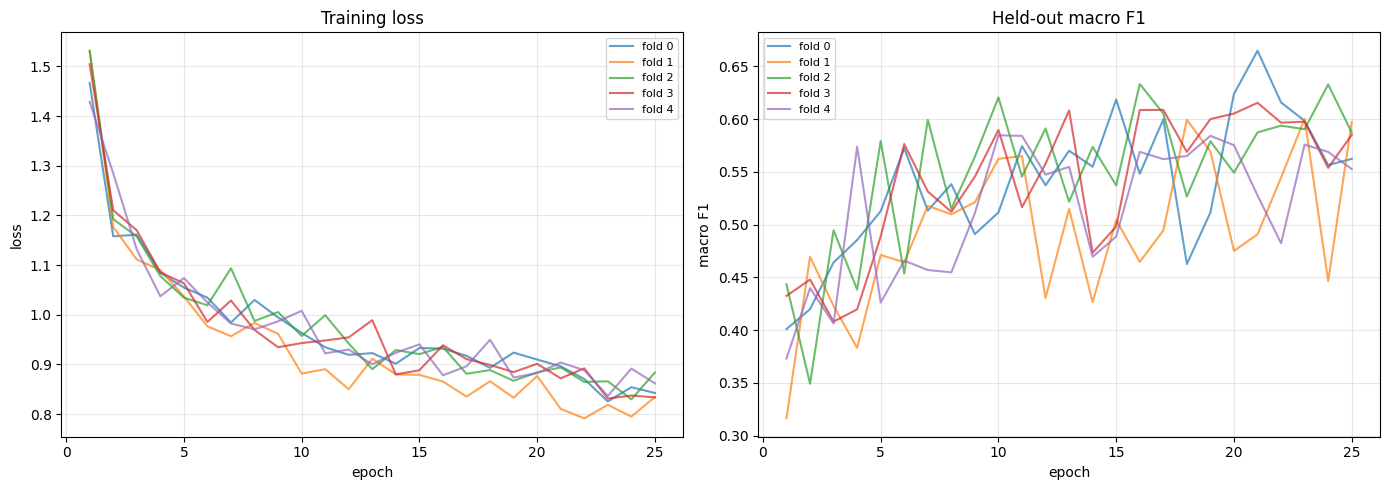

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for fold, g in history_df.groupby("fold"):
    axes[0].plot(g["epoch"], g["train_loss"], alpha=0.7, label=f"fold {fold}")
    axes[1].plot(g["epoch"], g["test_f1"], alpha=0.7, label=f"fold {fold}")

axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].set_title("Held-out macro F1")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:** The training loss keeps falling (1.47 down to 0.87 in fold 0), but the **held-out score stops improving after about epoch 5**. After that it bounces between roughly 0.40 and 0.62 from one epoch to the next.

This is not the usual overfitting picture — the held-out loss stays low instead of climbing. The model has reached its limit early and is now just wobbling around it. The bouncing comes from the rare classes: with only 5 or 6 "Vertical" images in a held-out fold, a couple of predictions changing moves macro F1 by several points.

Two conclusions follow. Training for longer would not help, so 25 epochs is fine. And what limits the model is its design and the small dataset, not the training time — which is exactly what transfer learning should improve.

One oddity: the held-out loss is *lower* than the training loss. That is expected here, because training images are augmented and therefore harder, while held-out images are not.

## 6. Results

**What:** Score the predictions collected across all five folds.

**Why report it this way?** Every image now has a prediction from a model that never saw it during training, so these numbers reflect genuinely unseen data.

We report three things:

- **Macro F1** — our headline. It averages the score across all nine classes equally, so failing on the rare defects cannot be hidden by succeeding on the common ones.
- **Accuracy** — reported for context only. On its own it is misleading here, since 60% of the data is a single class.
- **Recall for each class** — of all the images that really were, say, "Vertical", what fraction did we correctly identify? In a factory this is the number that matters most: a missed defect ships to the customer.

In [11]:
macro_f1 = f1_score(oof_true, oof_pred, average="macro", zero_division=0)
accuracy = (oof_pred == oof_true).mean()

print(f"Overall macro F1 : {macro_f1:.3f}")
print(f"Overall accuracy : {accuracy:.3f}")
print()
print(classification_report(oof_true, oof_pred, target_names=class_names,
                            digits=3, zero_division=0))

Overall macro F1 : 0.583
Overall accuracy : 0.837

                precision    recall  f1-score   support

 Broken stitch      0.800     0.250     0.381       112
   Needle mark      0.589     0.954     0.728       108
Pinched fabric      0.823     0.944     0.879       108
      Vertical      0.250     0.148     0.186        27
   defect free      0.993     0.906     0.947      1663
          hole      0.492     0.206     0.290       141
    horizontal      0.261     0.676     0.377        34
         lines      0.538     0.726     0.618       146
         stain      0.738     0.977     0.841       398

      accuracy                          0.837      2737
     macro avg      0.609     0.643     0.583      2737
  weighted avg      0.859     0.837     0.831      2737



**Observations:** **Macro F1 is 0.583 and accuracy is 0.837.** The gap between the two is the important part. Accuracy looks strong only because "defect free" is 60% of the data and the model handles it well (F1 0.947). Macro F1 counts all nine classes equally and gives a much more realistic picture.

The results split sharply by class:

| Handled well | F1 | Handled badly | F1 |
|---|---|---|---|
| defect free | 0.947 | Vertical | 0.186 |
| Pinched fabric | 0.879 | hole | 0.290 |
| stain | 0.841 | horizontal | 0.377 |
| Needle mark | 0.728 | Broken stitch | 0.381 |
| lines | 0.618 | | |

Look at precision and recall separately and a pattern appears. **Broken stitch** is precise but blind: when it says "Broken stitch" it is right 80% of the time, yet it finds only 25% of them. **horizontal** is the opposite — it finds 68% of them but is right only 26% of the time it makes that call. **Needle mark** and **stain** behave the same way, with recall far above precision.

That is the class weighting at work, and slightly overshooting. Punishing missed rare defects heavily pushes the model to guess those classes too freely, so it catches more of them but raises a lot of false alarms in the process.

In [12]:
recalls = recall_score(oof_true, oof_pred, average=None, zero_division=0)
counts = manifest["class"].value_counts()

rare = pd.DataFrame({
    "class": class_names,
    "images": [counts[c] for c in class_names],
    "recall": recalls,
}).sort_values("images")

print("Recall by class, rarest first:")
print(rare.to_string(index=False))

Recall by class, rarest first:
         class  images   recall
      Vertical      27 0.148148
    horizontal      34 0.676471
Pinched fabric     108 0.944444
   Needle mark     108 0.953704
 Broken stitch     112 0.250000
          hole     141 0.205674
         lines     146 0.726027
         stain     398 0.977387
   defect free    1663 0.905592


**Observations:** **Being rare is not what makes a class hard.**

Two classes of almost identical size make the point: "Pinched fabric" (108 images) reaches **0.944** recall while "Broken stitch" (112 images) manages **0.250**. And "hole", with 141 images, scores **0.206** — worse than "horizontal", which has only 34.

So the number of images is not the problem. What matters is whether a class looks like another class. The confusion matrix below shows which pairs get mixed up.

### Rare-defect recall, checked separately

**What:** Break the rare classes' recall down fold by fold, instead of only reporting one pooled number.

**Why:** Macro F1 is our main measure, but it averages across all nine classes and can hide a rare class doing badly. Reporting rare-defect recall separately is what shows whether the small classes are genuinely being found.

Splitting it by fold matters because these classes are tiny. "Vertical" has only 5 or 6 images in each held-out fold, so one prediction changing moves its recall by about 17 points. A single pooled figure gives no sense of how unstable it is.

In [13]:
RARE_CLASSES = [c for c in class_names if counts[c] < 150 and c != "defect free"]

rows = []
for fold in sorted(manifest["fold"].unique()):
    mask = manifest["fold"].values == fold
    for cls in RARE_CLASSES:
        idx = cls_to_idx[cls]
        actual = (oof_true == idx) & mask
        if actual.sum() == 0:
            continue
        rows.append({
            "class": cls,
            "fold": fold,
            "n_test": int(actual.sum()),
            "recall": float((oof_pred[actual] == idx).mean()),
        })

rare_df = pd.DataFrame(rows)
per_fold = rare_df.pivot(index="class", columns="fold", values="recall")
per_fold["pooled"] = [recalls[cls_to_idx[c]] for c in per_fold.index]
per_fold["spread"] = per_fold.iloc[:, :-1].max(axis=1) - per_fold.iloc[:, :-1].min(axis=1)
per_fold["images"] = [counts[c] for c in per_fold.index]
per_fold = per_fold.sort_values("images")

print(f"Rare classes (fewer than 150 images): {', '.join(RARE_CLASSES)}\n")
print("Recall per fold:")
print(per_fold.to_string(float_format=lambda v: f"{v:.3f}"))

print(f"\nMean recall across rare classes: "
      f"{per_fold['pooled'].mean():.3f}")
print(f"Widest fold-to-fold swing        : {per_fold['spread'].max():.3f} "
      f"({per_fold['spread'].idxmax()})")

Rare classes (fewer than 150 images): Broken stitch, Needle mark, Pinched fabric, Vertical, hole, horizontal, lines

Recall per fold:
fold               0     1     2     3     4  pooled  spread  images
class                                                               
Vertical       0.400 0.000 0.000 0.167 0.167   0.148   0.400      27
horizontal     0.286 1.000 1.000 0.167 0.857   0.676   0.833      34
Pinched fabric 1.000 1.000 1.000 0.952 0.762   0.944   0.238     108
Needle mark    0.905 0.952 0.909 1.000 1.000   0.954   0.095     108
Broken stitch  0.217 0.348 0.273 0.227 0.182   0.250   0.166     112
hole           0.143 0.286 0.179 0.276 0.143   0.206   0.143     141
lines          0.690 0.586 0.897 0.800 0.655   0.726   0.310     146

Mean recall across rare classes: 0.558
Widest fold-to-fold swing        : 0.833 (horizontal)


**Observations:** The pooled figures hide a great deal. Broken down by fold, the rare classes are far less stable than the overall macro F1 spread of ±0.019 suggested.

**"horizontal" swings from 0.167 to 1.000** — the entire possible range. With only 6 or 7 test images per fold, that is the difference between finding one and finding all of them. Its pooled recall of 0.676 is an average of wildly different outcomes, not a reliable measure of performance.

**"Vertical" scores 0.000 in two of the five folds.** The model found none of its defects at all in those folds. Its pooled 0.148 therefore describes something closer to chance than to skill.

By contrast, the classes with around 100 or more images are steady: "Needle mark" varies by only 0.095 across folds, "hole" by 0.143, "Broken stitch" by 0.166. They are consistently good or consistently bad, which is at least a measurement.

**The conclusion for the report:** for "Vertical" and "horizontal", any single recall figure should be quoted as approximate, with the range given alongside. There are simply not enough images to say more than that. This is a limit of the dataset rather than of the model, and no amount of extra training will fix it.

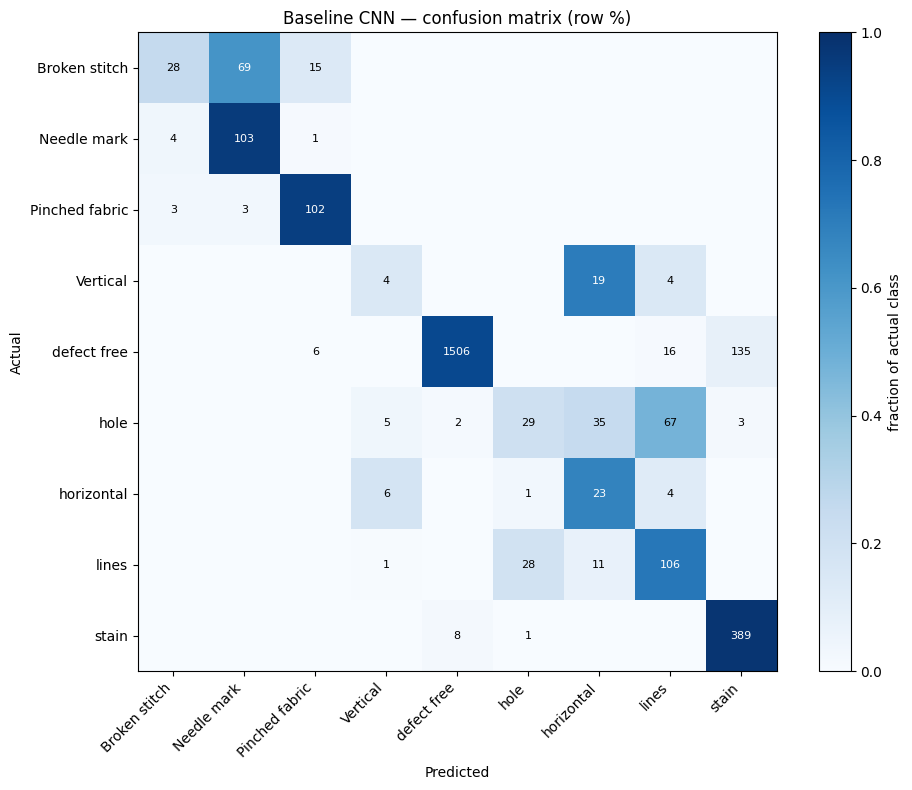

In [14]:
cm = confusion_matrix(oof_true, oof_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(n_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Baseline CNN — confusion matrix (row %)")

for i in range(n_classes):
    for j in range(n_classes):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm_pct[i, j] > 0.5 else "black")

plt.colorbar(im, label="fraction of actual class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:** The mistakes are not spread evenly. They fall into a few specific pairs.

**Broken stitch is called Needle mark 69 times out of 112.** The biggest single failure, and it explains why Broken stitch finds only a quarter of its cases. The two classes come from the same source collection and are both 224×224 close-ups of fabric, so they look alike.

**Vertical is called horizontal 19 times out of 27**, with only 4 correct. Almost every vertical defect is given the wrong direction. This is striking given that we deliberately avoided 90° rotations in the augmentation to protect these two classes. That choice was right but nowhere near enough — the classes are too similar, and 27 images is too few to learn the difference.

**hole is scattered across several classes:** only 29 of 141 are correct, with 67 called "lines" and 35 called "horizontal". "lines" gets confused back into "hole" 28 times. These three share source collections and all show thin dark marks on fabric.

**The safety picture is good.** Only **10 defective images out of 1,074 (0.9%)** are called "defect free" — 8 stains and 2 holes. In a factory these are the expensive mistakes, because a faulty roll reaches the customer. Against that, **157 of the 1,663 clean images (9.4%)** are flagged as defective, mostly as "stain".

That is the right trade to make. A false alarm costs someone a second look at a good roll; a missed defect costs a returned order. The model errs heavily towards caution, which is what the class weighting was designed to encourage.

Almost every remaining mistake is one defect type being called another rather than a defect being missed entirely. The model reliably notices that something is wrong, and often gets the type wrong — a considerably easier problem to improve on.

## 7. Save the Results

**What:** Write the scores, per-epoch history, and predictions to disk.

**Why:** Notebook 04 needs these numbers to compare ResNet18 against this baseline CNN. Saving the per-image predictions also means we can revisit specific mistakes later without retraining anything.

**Why save the settings as well as the weights.** A saved model is just a list of numbers. Anything loading it later has to know which class each output position means, what size images to expect, and which normalisation values were used. Without those, the weights cannot be turned back into a working classifier — so they are written to a small config file alongside.

In [15]:
scores_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_fold_scores.csv", index=False)
history_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_history.csv", index=False)

pred_df = manifest.copy()
pred_df["predicted"] = [class_names[i] for i in oof_pred]
pred_df["correct"] = pred_df["predicted"] == pred_df["class"]
pred_df.to_csv(RESULTS_DIR / f"{MODEL_NAME}_predictions.csv", index=False)

summary = {
    "model": "SimpleCNN (from scratch)",
    "n_images": int(len(manifest)),
    "n_classes": int(n_classes),
    "n_folds": int(manifest["fold"].nunique()),
    "epochs": EPOCHS,
    "parameters": int(n_params),
    "macro_f1": float(macro_f1),
    "accuracy": float(accuracy),
    "per_class_recall": {c: float(r) for c, r in zip(class_names, recalls)},
}
with open(RESULTS_DIR / f"{MODEL_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

model_config = {
    "architecture": "SimpleCNN",
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "dropout": 0.5,
    "weight_files": [f"{MODEL_NAME}_fold{f}.pt"
                     for f in sorted(manifest["fold"].unique())],
}
with open(MODELS_DIR / f"{MODEL_NAME}_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Saved to", RESULTS_DIR.resolve())
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"   {f.name:38s} {f.stat().st_size / 1024:8.1f} KB")

cm_file = RESULTS_DIR / f"{MODEL_NAME}_confusion_matrix.png"
if ASSETS_DIR is not None and cm_file.exists():
    import shutil
    shutil.copy2(cm_file, ASSETS_DIR / cm_file.name)
    print(f"\nCopied {cm_file.name} -> {ASSETS_DIR / cm_file.name}")

print("\nModels:", MODELS_DIR)
for f in sorted(MODELS_DIR.glob(f"{MODEL_NAME}*")):
    print(f"   {f.name:34s} {f.stat().st_size / 1024:8.1f} KB")

Saved to /content/outputs/baseline_cnn
   baseline_cnn_confusion_matrix.png          98.2 KB
   baseline_cnn_fold_scores.csv                0.2 KB
   baseline_cnn_history.csv                    9.9 KB
   baseline_cnn_predictions.csv              211.9 KB
   baseline_cnn_summary.json                   0.5 KB

Models: /content/models
   baseline_cnn_config.json                0.5 KB
   baseline_cnn_fold0.pt                1544.6 KB
   baseline_cnn_fold1.pt                1544.6 KB
   baseline_cnn_fold2.pt                1544.6 KB
   baseline_cnn_fold3.pt                1544.6 KB
   baseline_cnn_fold4.pt                1544.6 KB


## 8. Summary

### What this notebook did

1. Loaded the 2,737 cleaned images from Notebook 02, along with their fold assignments and class weights.
2. Set up augmentation that avoids 90° rotations, since those would turn a "Vertical" defect into a "horizontal" one and create wrongly labelled training data.
3. Built a small four-block CNN from scratch — no outside knowledge, trained only on this dataset.
4. Trained it five times using cross-validation, so every image was tested by a model that had never seen it.
5. Reported macro F1 and per-class recall across every image in the dataset.

### Headline results

| Measure | Result |
|---|---|
| **Macro F1** (main metric) | **0.583** |
| Accuracy | 0.837 |
| **Rare-defect recall** | Vertical **0.148** (range 0.00–0.40 across folds), horizontal **0.676** (range 0.17–1.00) |
| Weakest classes overall | hole 0.206, Broken stitch 0.250 |
| Defects passed as normal | 10 of 1,074 (0.9%) |
| Clean fabric wrongly flagged | 157 of 1,663 (9.4%) |

The two rare classes are quoted with their range because a single figure would overstate how much is known: "horizontal" scored anywhere from 0.167 to 1.000 depending on the fold, and "Vertical" found nothing at all in two of the five.

### Files produced

Each model writes into its own folder under `outputs/`, so Notebook 04's ResNet18 results sit beside these rather than mixed in with them:

```
outputs/
│
├── baseline_cnn/
│   ├── baseline_cnn_summary.json
│   ├── baseline_cnn_fold_scores.csv
│   ├── baseline_cnn_history.csv
│   ├── baseline_cnn_predictions.csv
│   └── baseline_cnn_confusion_matrix.png
│
└── resnet18/            ← created by Notebook 04
    └── ...
```

| File | Contents |
|---|---|
| `baseline_cnn_summary.json` | Headline scores and per-class recall |
| `baseline_cnn_fold_scores.csv` | Macro F1 and accuracy for each fold |
| `baseline_cnn_history.csv` | Loss and F1 after every epoch |
| `baseline_cnn_predictions.csv` | The prediction for every image |
| `baseline_cnn_confusion_matrix.png` | Confusion matrix figure |

Trained weights are written to `models/`:

| File | Contents |
|---|---|
| `baseline_cnn_fold0.pt` … `fold4.pt` | Trained weights, one per fold (1.6 MB each) |
| `baseline_cnn_config.json` | Class order, image size, normalisation values |

These are small enough to keep in the repository, so the model can be loaded and used without retraining.

Keeping the model name in both the folder and the filenames is deliberate: it means a file stays identifiable if it is copied into a report or attached to an email, away from its folder.

### Decisions worth defending

- **No 90° rotations in augmentation.** They would relabel "Vertical" as "horizontal" while leaving the label untouched, damaging the two smallest and hardest classes.
- **Weighted loss rather than duplicating rare images.** With only ~32 "Vertical" images, copying them would teach the model to memorise those 32 pictures.
- **A fixed 25 epochs rather than stopping early.** Stopping early would require watching the held-out fold, and that fold is what we report our score on — deciding when to stop by looking at it would flatter the result.
- **Cross-validation rather than one split.** It gives roughly 32 test predictions for "Vertical" instead of about 5, which is the difference between a measurement and a guess.

### Next: Notebook 04

Train **ResNet18** using transfer learning, with the same folds, the same augmentation and the same metrics, so the comparison is fair. The question it answers: does starting from a network already trained on millions of photographs beat the 0.583 macro F1 achieved by learning from these 2,737 fabric images alone?

The confusion matrix gives it specific targets — the Broken stitch / Needle mark collapse (69 of 112), the Vertical / horizontal mix-up (19 of 27), and the 157 clean rolls wrongly flagged as defective.